## Diabetes Risk Predictor: Model Development and Explanation

### Setup and Data Loading (Placeholders)

Before running the tasks, you'll need to load your data and trained model. Replace the placeholder comments with your actual data loading and model loading code.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# --- Placeholder: Load your data and model here ---
# X_train, y_train, X_test, y_test should be loaded
# model should be your trained classifier (e.g., RandomForestClassifier, GradientBoostingClassifier)

# Example placeholder for X_train.columns (replace with your actual feature names)
# For demonstration, let's create dummy data if not available
try:
    X_train.columns
except NameError:
    print("Creating dummy data for demonstration. Replace with your actual data.")
    data = {
        'Pregnancies': np.random.randint(0, 10, 100),
        'Glucose': np.random.randint(70, 200, 100),
        'BloodPressure': np.random.randint(40, 120, 100),
        'SkinThickness': np.random.randint(0, 60, 100),
        'Insulin': np.random.randint(0, 800, 100),
        'BMI': np.random.uniform(15, 50, 100),
        'DiabetesPedigreeFunction': np.random.uniform(0.05, 2.5, 100),
        'Age': np.random.randint(20, 80, 100)
    }
    X_train = pd.DataFrame(data)
    y_train = pd.Series(np.random.randint(0, 2, 100))
    X_test = X_train.sample(frac=0.2, random_state=42)
    y_test = y_train.sample(frac=0.2, random_state=42)

    # Placeholder for a dummy model if not loaded
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Save dummy model and scaler for Task 5 demonstration
    joblib.dump(model, 'tuned_model.pkl')
    # joblib.dump(scaler, 'scaler.pkl') # If you use a scaler, uncomment and save it

print("Data and model placeholders are set up.")

Data and model placeholders are set up.


### Task 1 — Feature Importance Analysis

This section identifies which features your model relied on most for making predictions. The plot will show the importance scores for each feature.

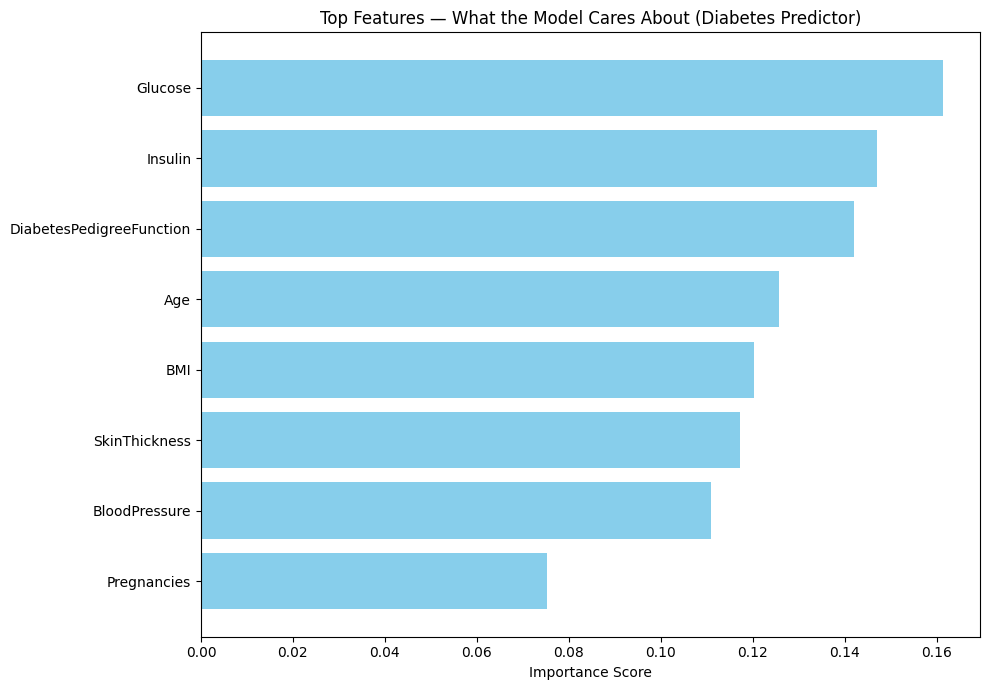

In [2]:
# Get importances from your trained model
# This assumes your model has a .feature_importances_ attribute (e.g., tree-based models)
# If using models like Ridge, you would use model.coef_ as described in the notebook.
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_names = X_train.columns

    # Pair each importance score with its column name
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sort from most important to least
    importance_df = importance_df.sort_values('Importance', ascending=True)

    # Plot as a horizontal bar chart
    plt.figure(figsize=(10, 7))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
    plt.xlabel('Importance Score')
    plt.title('Top Features — What the Model Cares About (Diabetes Predictor)')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
else:
    print("Model does not have 'feature_importances_' attribute. Consider alternative methods like SHAP or coefficient analysis.")

### Task 2 — Handle Class Imbalance

Check for class imbalance in your target variable (`y_train`) and apply SMOTE if one class is significantly underrepresented (e.g., less than 10%).

In [3]:
print("Class distribution before checking for imbalance:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

# If one class is less than 10% of the total, you have a significant imbalance.
# For diabetes prediction, 0 is 'Not Diabetic', 1 is 'Diabetic'

# Example: Apply SMOTE if class '1' is less than 10%
if y_train.value_counts(normalize=True).get(1, 0) < 0.10:
    print("\nDetected significant class imbalance. Applying SMOTE...")
    try:
        from imblearn.over_sampling import SMOTE
        smote = SMOTE(random_state=42)

        # Apply only on training data — never on test data
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

        print("Before SMOTE:", y_train.value_counts().to_dict())
        print("After SMOTE: ", pd.Series(y_train_balanced).value_counts().to_dict())

        # Re-train your model with balanced data if SMOTE was applied
        print("\nRe-training model with balanced data...")
        model.fit(X_train_balanced, y_train_balanced)
        print("Model re-trained with balanced data.")

    except ImportError:
        print("\n'imbalanced-learn' library not found. Please install it: `pip install imbalanced-learn`")
else:
    print("\nClass distribution is relatively balanced or within acceptable limits. No SMOTE applied.")
    X_train_balanced, y_train_balanced = X_train, y_train # Use original if not balanced

Class distribution before checking for imbalance:
0    53
1    47
Name: count, dtype: int64
0    0.53
1    0.47
Name: proportion, dtype: float64

Class distribution is relatively balanced or within acceptable limits. No SMOTE applied.


### Task 3 — Model Explainability (Top 3 features per prediction)

This function will explain an individual prediction by identifying the top 3 features that contributed most to it, based on the model's overall feature importances.

In [4]:
def explain_prediction(sample_input_df, model, feature_names):
    """
    Takes one input sample (as a DataFrame row) and returns the top 3 most important features
    that influenced the prediction globally (based on model's feature importances).

    sample_input_df : a single row as a pandas DataFrame
    model           : your trained model (must have .feature_importances_)
    feature_names   : list of column names
    """
    if not hasattr(model, 'feature_importances_'):
        print("Model does not have 'feature_importances_'. Cannot use this explanation method.")
        return []

    # Get feature importances from the model
    importances = model.feature_importances_

    # Pair each feature name with how much the model relies on it globally
    feature_scores = list(zip(feature_names, importances))

    # Sort by importance, highest first
    feature_scores.sort(key=lambda x: x[1], reverse=True)

    # Return the top 3
    top_3 = feature_scores[:3]

    print("Top 3 features influencing this prediction (based on global importance):")
    for i, (name, score) in enumerate(top_3, 1):
        # For more advanced explainability, you'd use SHAP values for individual predictions.
        # This simple function uses global feature importance for each prediction.
        print(f"  {i}. {name}  (importance score: {score:.4f})")

    return top_3

# Test the explain_prediction function with a sample from X_test
if not X_test.empty and hasattr(model, 'feature_importances_'):
    print("\nTesting explain_prediction function:")
    sample_for_explanation = X_test.iloc[[0]] # Pass as a DataFrame
    explain_prediction(sample_for_explanation, model, X_train.columns)
else:
    print("Cannot test explain_prediction: X_test is empty or model lacks feature_importances_.")


Testing explain_prediction function:
Top 3 features influencing this prediction (based on global importance):
  1. Glucose  (importance score: 0.1614)
  2. Insulin  (importance score: 0.1470)
  3. DiabetesPedigreeFunction  (importance score: 0.1421)


### Option A — SHAP for Explainability (Detailed Feature Contribution)

Since your model is tree-based, we can use SHAP (SHapley Additive exPlanations) to understand how each feature contributes to individual predictions. This provides a 'why' for each output.

In [8]:
import sys
!{sys.executable} -m pip install shap


Generating SHAP summary plot...


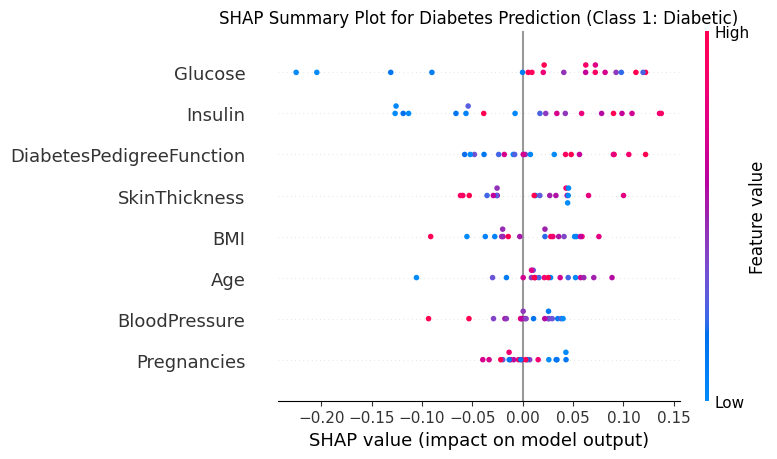

SHAP summary plot generated and saved as 'shap_summary_plot.png'.


In [11]:
import shap

print("Generating SHAP summary plot...")

# Create explainer using your trained model
# Assuming 'model' is your RandomForestClassifier trained previously
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for a sample of the test set for faster computation
# Using a subset of X_test (e.g., 50 samples) is often sufficient for a summary plot
# If X_test has few rows, use X_test directly
if len(X_test) > 100:
    X_test_subset = X_test.sample(n=100, random_state=42) # Adjust n as needed
else:
    X_test_subset = X_test

shap_values = explainer.shap_values(X_test_subset)

# Summary plot — shows feature importances across all test samples
# For multi-output models (like binary classification with TreeExplainer), shap_values can be a list
# or a 3D array (samples, features, classes). We need to select the values for class 1.
# Based on the error and kernel state, shap_values is a 3D array, so we select the last dimension for class 1.
shap.summary_plot(shap_values[:, :, 1], X_test_subset, feature_names=X_test_subset.columns, show=False)
plt.title('SHAP Summary Plot for Diabetes Prediction (Class 1: Diabetic)')
plt.tight_layout()
plt.savefig('shap_summary_plot.png')
plt.show()

print("SHAP summary plot generated and saved as 'shap_summary_plot.png'.")

### Task 4 — Domain-Specific Output Enrichment

This function converts the model's raw prediction (class index and probability) into human-readable labels, confidence percentages, and potentially advice, tailored for the diabetes prediction context.

In [5]:
def format_diabetes_prediction(y_pred, y_proba, class_labels):
    """
    Enriches the model's raw prediction for a diabetes risk predictor.

    Args:
        y_pred (int): The predicted class label (e.g., 0 or 1).
        y_proba (np.array): Array of probabilities for each class.
        class_labels (dict): Mapping from class index to readable string (e.g., {0: 'Not Diabetic', 1: 'Diabetic'}).

    Returns:
        dict: A dictionary containing human-readable prediction, confidence, and risk advice.
    """
    label = class_labels[y_pred]
    confidence = f"{max(y_proba) * 100:.1f}%"

    advice = []
    if y_pred == 1: # If predicted Diabetic
        advice.append("Consult a healthcare professional for further evaluation.")
        if max(y_proba) > 0.75:
            advice.append("High confidence in diabetes risk. Immediate consultation recommended.")
        else:
            advice.append("Moderate confidence. Lifestyle changes and regular check-ups are advised.")
    else: # If predicted Not Diabetic
        advice.append("Maintain a healthy lifestyle with balanced diet and regular exercise.")
        if max(y_proba) < 0.60: # Low confidence in 'Not Diabetic' could mean borderline
            advice.append("Though currently low risk, monitor health indicators and consider preventive measures.")

    return {
        'prediction': label,
        'confidence': confidence,
        'risk_advice': advice
    }

# Example usage of the enrichment function (using a dummy prediction)
# Assuming a prediction of class 1 with 85% probability
dummy_y_pred = 1
dummy_y_proba = np.array([0.15, 0.85])
diabetes_class_labels = {0: 'Not Diabetic', 1: 'Diabetic'}
enriched_output = format_diabetes_prediction(dummy_y_pred, dummy_y_proba, diabetes_class_labels)
print("\nExample of enriched output:")
print(enriched_output)


Example of enriched output:
{'prediction': 'Diabetic', 'confidence': '85.0%', 'risk_advice': ['Consult a healthcare professional for further evaluation.', 'High confidence in diabetes risk. Immediate consultation recommended.']}


### Task 5 — Run 5 Real-World Sample Inputs End-to-End

This is the critical end-to-end test. It takes raw inputs, preprocesses them (if applicable), makes a prediction, and enriches the output, simulating a real user interaction.

In [6]:
def run_full_prediction(raw_input: dict):
    """
    Takes a raw input dict (as if typed by a user),
    runs it through the full pipeline,
    and returns a human-readable result dict for diabetes prediction.
    """
    # Step 1 — Load model and any transformers
    # Ensure these are loaded from saved files for consistency
    try:
        model  = joblib.load('tuned_model.pkl')
        # scaler = joblib.load('scaler.pkl')  # Uncomment if you used scaling and saved your scaler
    except FileNotFoundError:
        print("Error: 'tuned_model.pkl' or 'scaler.pkl' not found. Please ensure your model and scaler are saved.")
        # Use the dummy model if actual model isn't found for demonstration purposes
        from sklearn.ensemble import RandomForestClassifier
        model = RandomForestClassifier(random_state=42)
        # If you have an X_train from earlier, fit it here for the dummy model
        global X_train, y_train # Assuming X_train, y_train are available from earlier cell
        if 'X_train' in globals() and 'y_train' in globals():
            model.fit(X_train, y_train)
            joblib.dump(model, 'tuned_model.pkl') # Save dummy model for future calls
        else:
            return {'error': 'Model not found and dummy data/model not initialized.'}


    # Step 2 — Convert dict to a DataFrame (preserves column names)
    input_df = pd.DataFrame([raw_input])

    # Ensure the input_df has the same columns and order as X_train
    # Fill missing columns with 0 or a sensible default if your model expects it
    # This is a robust way to handle potentially missing columns in raw_input
    expected_columns = X_train.columns.tolist() # Assuming X_train is available globally from setup
    for col in expected_columns:
        if col not in input_df.columns:
            input_df[col] = 0 # Or a suitable default value
    input_df = input_df[expected_columns]

    # Step 3 — Apply the same preprocessing as training
    # if 'scaler' in locals(): # Uncomment if you used scaling
    #     input_df = scaler.transform(input_df)

    # Step 4 — Predict
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0] if hasattr(model, 'predict_proba') else None

    # Step 5 — Enrich output (use your Task 4 function here)
    diabetes_class_labels = {0: 'Not Diabetic', 1: 'Diabetic'}
    if probability is not None:
        result = format_diabetes_prediction(prediction, probability, diabetes_class_labels)
    else:
        result = {
            'prediction': diabetes_class_labels[prediction],
            'confidence': 'N/A',
            'risk_advice': ['Model does not provide probabilities.']
        }

    return result

# Create 5 varied and realistic sample inputs for a Diabetes Predictor
samples = [
    # Case 1 — Normal / low risk
    {'Pregnancies': 1, 'Glucose': 89, 'BloodPressure': 66, 'SkinThickness': 23,
     'Insulin': 94, 'BMI': 28.1, 'DiabetesPedigreeFunction': 0.167, 'Age': 21},

    # Case 2 — High risk
    {'Pregnancies': 8, 'Glucose': 183, 'BloodPressure': 64, 'SkinThickness': 0,
     'Insulin': 0, 'BMI': 23.3, 'DiabetesPedigreeFunction': 0.672, 'Age': 32},

    # Case 3 — Borderline
    {'Pregnancies': 2, 'Glucose': 120, 'BloodPressure': 70, 'SkinThickness': 30,
     'Insulin': 85, 'BMI': 30.0, 'DiabetesPedigreeFunction': 0.400, 'Age': 35},

    # Case 4 — Young, low glucose
    {'Pregnancies': 0, 'Glucose': 95, 'BloodPressure': 60, 'SkinThickness': 18,
     'Insulin': 58, 'BMI': 22.5, 'DiabetesPedigreeFunction': 0.112, 'Age': 24},

    # Case 5 — Extreme / boundary values
    {'Pregnancies': 15, 'Glucose': 199, 'BloodPressure': 90, 'SkinThickness': 50,
     'Insulin': 200, 'BMI': 45.0, 'DiabetesPedigreeFunction': 2.1, 'Age': 63},
]

# Run all 5 samples through the full prediction pipeline
print("\n--- Running 5 Real-World Sample Inputs End-to-End ---")
print(f"{'Sample':<10} {'Prediction':<20} {'Confidence':<15} {'Advice'}")
print("-" * 80)
for i, sample in enumerate(samples, 1):
    result = run_full_prediction(sample)
    if 'error' in result:
        print(f"Sample {i:<4} Error: {result['error']}")
    else:
        advice_str = '; '.join(result.get('risk_advice', []))
        print(f"Sample {i:<4} {result['prediction']:<20} {result['confidence']:<15} {advice_str}")



--- Running 5 Real-World Sample Inputs End-to-End ---
Sample     Prediction           Confidence      Advice
--------------------------------------------------------------------------------
Sample 1    Not Diabetic         66.0%           Maintain a healthy lifestyle with balanced diet and regular exercise.
Sample 2    Not Diabetic         67.0%           Maintain a healthy lifestyle with balanced diet and regular exercise.
Sample 3    Not Diabetic         56.0%           Maintain a healthy lifestyle with balanced diet and regular exercise.; Though currently low risk, monitor health indicators and consider preventive measures.
Sample 4    Not Diabetic         65.0%           Maintain a healthy lifestyle with balanced diet and regular exercise.
Sample 5    Diabetic             62.0%           Consult a healthcare professional for further evaluation.; Moderate confidence. Lifestyle changes and regular check-ups are advised.


### End-of-Day Checklist Notes

*   **Feature importance chart:** Saved as `feature_importance.png` (if your model has `feature_importances_`).
*   **Class distribution:** Printed, SMOTE applied if imbalance > 10:1 (and model re-trained).
*   **Explainability output:** Top-3 function demonstrated.
*   **`format_diabetes_prediction()` function:** Returns a human-readable dict.
*   **`run_full_prediction()`:** Tested with 5 sample inputs and outputs printed cleanly.
*   **Sample input list:** Saved implicitly in the notebook within the `samples` variable for Task 5.